<a href="https://colab.research.google.com/github/khadija2027/Medical-image-classification-using-QCNN/blob/main/CNN%20VS%20QCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL AND IMPORT**

In [2]:
!pip install medmnist -q
!pip install pennylane -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import time
import pennylane as qml
import os
import pickle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 106.6 MB/s eta 0:00:00


**Data pre-processing**

In [3]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
DRIVE_PATH = '/content/drive/MyDrive/Codes/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# DATA TRANSFORMS
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# LOAD DATASET
train_dataset = PneumoniaMNIST(split="train", download=True, size=28, transform=train_transform)
val_dataset = PneumoniaMNIST(split="val", download=True, size=28, transform=val_transform)
test_dataset = PneumoniaMNIST(split="test", download=True, size=28, transform=val_transform)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# CREATE DATALOADERS
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Mounted at /content/drive
Using device: cpu


100%|██████████| 4.17M/4.17M [00:02<00:00, 1.45MB/s]


Train: 4708, Val: 524, Test: 624


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Total parameters: 11,233,473
TRAINING MODIFIED RESNET-18
Epoch 1/50 | Train Loss: 0.1958 | Train Acc: 0.9153 | Val Loss: 0.4967 | Val Acc: 0.7977 | Time: 9.10s
✅ Best model saved to: /content/drive/MyDrive/Codes/best_resnet_model.pth
Epoch 2/50 | Train Loss: 0.1364 | Train Acc: 0.9452 | Val Loss: 0.9958 | Val Acc: 0.7309 | Time: 9.39s
Epoch 3/50 | Train Loss: 0.1213 | Train Acc: 0.9537 | Val Loss: 0.1714 | Val Acc: 0.9218 | Time: 7.63s
✅ Best model saved to: /content/drive/MyDrive/Codes/best_resnet_model.pth
Epoch 4/50 | Train Loss: 0.1086 | Train Acc: 0.9596 | Val Loss: 0.1030 | Val Acc: 0.9599 | Time: 7.46s
✅ Best model saved to: /content/drive/MyDrive/Codes/best_resnet_model.pth
Epoch 5/50 | Train Loss: 0.1061 | Train Acc: 0.9613 | Val Loss: 0.2969 | Val Acc: 0.9027 | Time: 5.66s
Epoch 6/50 | Train Loss: 0.0955 | Train Acc: 0.9667 | Val Loss: 0.2713 | Val Acc: 0.9027 | Time: 6.63s
Epoch 7/50 | Train Loss: 0.0873 | Train Acc: 0.9662 | Val Loss: 0.1559 | Val Acc: 0.9447 | Time: 4.73s


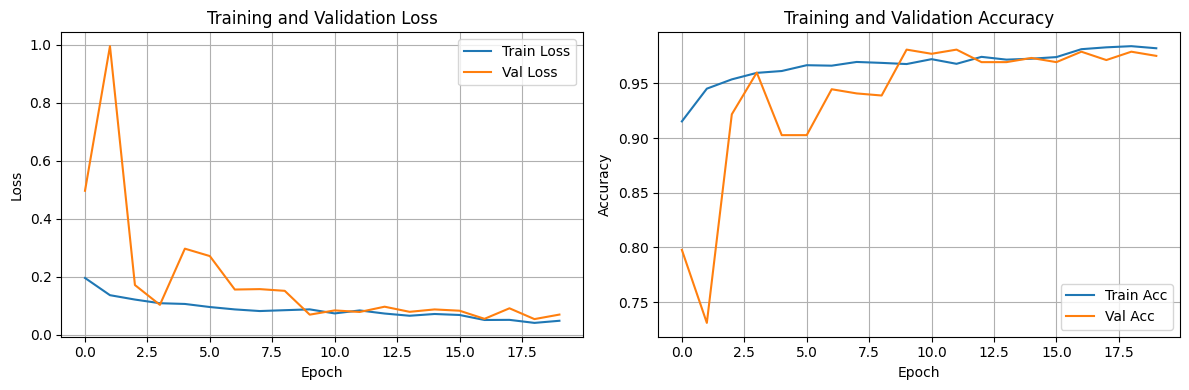


EVALUATING ON TEST SET
✅ Model loaded from: /content/drive/MyDrive/Codes/best_resnet_model.pth
Test Accuracy:  0.8494
Test Precision: 0.8096
Test Recall:    0.9923
Test F1 Score:  0.8917


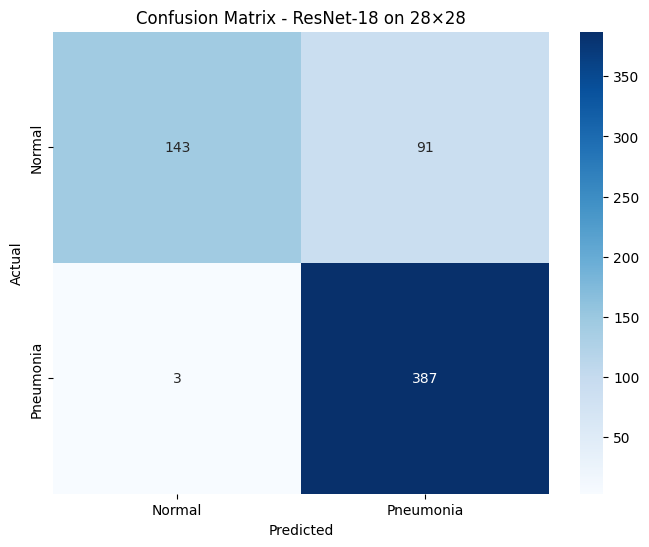

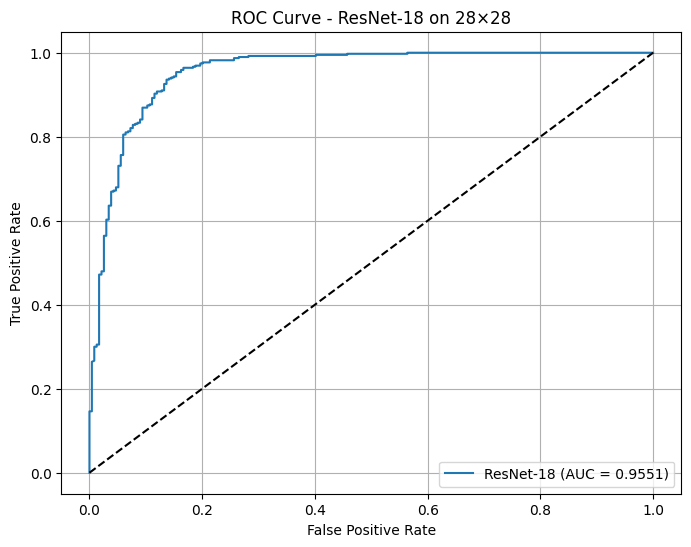


MODEL SUMMARY
Model: Modified ResNet-18 (28×28 input)
Total parameters: 11,233,473
Best validation accuracy: 0.9809
Test accuracy: 0.8494
Test F1 score: 0.8917
AUC Score: 0.9551

 Results saved to: /content/drive/MyDrive/Codes/resnet_results.pkl


In [ ]:
# ============ MODIFIED RESNET-18 FOR 28×28 ============
class ModifiedResNet18(nn.Module):
    """
    ResNet-18 modified to accept 28×28 grayscale images
    """
    def __init__(self, num_classes=1):
        super(ModifiedResNet18, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        self.resnet.conv1 = nn.Conv2d(
            in_channels=1,        # Grayscale input (was 3)
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # Remove maxpool to keep dimensions
        self.resnet.maxpool = nn.Identity()

        # Modify final fully connected layer for binary classification
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        # Store model
        self.model = self.resnet

    def forward(self, x):
        return self.model(x)

# ============ CREATE MODEL ============
model = ModifiedResNet18(num_classes=1).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============ DEFINE LOSS AND OPTIMIZER ============
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# ============ TRAINING FUNCTION ============
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch_idx, (data, targets) in enumerate(loader):
        data, targets = data.to(device), targets.to(device).float()

        # Forward pass
        outputs = model(data)
        loss = criterion(outputs.squeeze(), targets.squeeze())

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Store predictions for metrics
        preds = torch.sigmoid(outputs).squeeze()
        preds = (preds > 0.5).float()
        all_preds.extend(preds.cpu().detach().numpy())
        all_labels.extend(targets.cpu().detach().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

# ============ VALIDATION FUNCTION ============
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device).float()

            outputs = model(data)
            loss = criterion(outputs.squeeze(), targets.squeeze())

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).squeeze()
            preds = (preds > 0.5).float()
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(targets.cpu().detach().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

# ============ TRAINING LOOP ============
def train_model(model, train_loader, val_loader, epochs=50):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    patience = 10
    patience_counter = 0

    for epoch in range(epochs):
        start_time = time.time()

        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion)

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {time.time()-start_time:.2f}s")

        # Save best model to DRIVE (not local)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_path = DRIVE_PATH + 'best_resnet_model.pth'
            torch.save(model.state_dict(), model_path)
            print(f"✅ Best model saved to: {model_path}")
            patience_counter = 0
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return history, best_val_acc

# ============ TRAIN THE MODEL ============
print("="*50)
print("TRAINING MODIFIED RESNET-18")
print("="*50)

history, best_val_acc = train_model(model, train_loader, val_loader, epochs=50)

# ============ PLOT TRAINING HISTORY ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ============ EVALUATION FUNCTION ============
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device).float()

            outputs = model(data)
            probs = torch.sigmoid(outputs).squeeze()

            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# ============ LOAD BEST MODEL AND EVALUATE ============
print("\n" + "="*50)
print("EVALUATING ON TEST SET")
print("="*50)

# FIX: Load from DRIVE, not local
model_path = DRIVE_PATH + 'best_resnet_model.pth'

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f" Model loaded from: {model_path}")
else:
    # Fallback: try loading from local
    if os.path.exists('best_resnet_model.pth'):
        model.load_state_dict(torch.load('best_resnet_model.pth'))
        print(" Model loaded from local storage (fallback)")
    else:
        print(f"❌ Model not found at {model_path}")
        raise FileNotFoundError(f"Model file not found: {model_path}")

test_results = evaluate(model, test_loader)

print(f"Test Accuracy:  {test_results['accuracy']:.4f}")
print(f"Test Precision: {test_results['precision']:.4f}")
print(f"Test Recall:    {test_results['recall']:.4f}")
print(f"Test F1 Score:  {test_results['f1']:.4f}")

# ============ CONFUSION MATRIX ============
cm = confusion_matrix(test_results['labels'], test_results['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix - ResNet-18 on 28×28')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============ ROC CURVE ============
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(test_results['labels'], test_results['probabilities'])
auc = roc_auc_score(test_results['labels'], test_results['probabilities'])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ResNet-18 (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet-18 on 28×28')
plt.legend()
plt.grid(True)
plt.show()

# ============ SUMMARY ============
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Model: Modified ResNet-18 (28×28 input)")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Test accuracy: {test_results['accuracy']:.4f}")
print(f"Test F1 score: {test_results['f1']:.4f}")
print(f"AUC Score: {auc:.4f}")

# ============ SAVE FINAL RESULTS ============
import pickle
results = {
    'history': history,
    'test_results': test_results,
    'best_val_acc': best_val_acc,
    'auc': auc
}

results_path = DRIVE_PATH + 'resnet_results.pkl'
with open(results_path, 'wb') as f:
    pickle.dump(results, f)

print(f"\n Results saved to: {results_path}")

In [ ]:
n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    """
    Quantum circuit for processing a 2×2 image patch.
    Uses angle encoding with RY rotations.
    """
    # Angle Encoding: Map [-1,1] → [0, π]
    for i in range(4):
        angle = (inputs[i] + 1) * np.pi / 2
        qml.RY(angle, wires=i)

    # Variational Layers
    for layer in range(n_layers):
        for i in range(4):
            qml.RY(weights[layer, i], wires=i)

        # Entangling layers
        for i in range(3):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[3, 0])

    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

# ============ 9. QCNN MODEL ============
class QuantumConvLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=2):
        super(QuantumConvLayer, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.q_weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits)
        )
        self.qnode = quantum_circuit

    def forward(self, x):
        batch_size = x.shape[0]
        h, w = x.shape[2], x.shape[3]

        out_h = h // 2
        out_w = w // 2

        quantum_features = torch.zeros(batch_size, out_h, out_w, self.n_qubits)

        for i in range(0, h, 2):
            for j in range(0, w, 2):
                patch = x[:, :, i:i+2, j:j+2]
                patch = patch.reshape(batch_size, -1)

                for b in range(batch_size):
                    inputs = patch[b].detach().cpu().numpy()
                    weights = self.q_weights.detach().cpu().numpy()
                    result = self.qnode(inputs, weights)
                    quantum_features[b, i//2, j//2, :] = torch.tensor(result, dtype=torch.float32)

        return quantum_features.to(device)


class QuantumPoolingLayer(nn.Module):
    def __init__(self, pool_size=2):
        super(QuantumPoolingLayer, self).__init__()
        self.pool_size = pool_size

    def forward(self, x):
        batch_size = x.shape[0]
        h, w = x.shape[1], x.shape[2]
        n_qubits = x.shape[3]

        out_h = h // self.pool_size
        out_w = w // self.pool_size

        pooled_features = torch.zeros(batch_size, out_h, out_w, n_qubits)

        for i in range(0, h, self.pool_size):
            for j in range(0, w, self.pool_size):
                block = x[:, i:i+self.pool_size, j:j+self.pool_size, :]
                pooled = block.mean(dim=(1, 2))
                pooled_features[:, i//self.pool_size, j//self.pool_size, :] = pooled

        return pooled_features.to(device)


class TrueQCNN(nn.Module):
    def __init__(self):
        super(TrueQCNN, self).__init__()

        self.qconv = QuantumConvLayer(n_qubits=4, n_layers=2)
        self.qpool = QuantumPoolingLayer(pool_size=2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.qconv(x)
        x = self.qpool(x)
        x = self.classifier(x)
        return x

# ============ 10. CREATE QCNN MODEL ============
qcnn_model = TrueQCNN().to(device)
print(f"\nQCNN Parameters: {sum(p.numel() for p in qcnn_model.parameters()):,}")

# ============ 11. EVALUATION FUNCTION ============
def evaluate(model, loader):
    """Evaluate model on given dataloader."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device).float()

            outputs = model(data)
            probs = torch.sigmoid(outputs).squeeze()

            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# ============ 12. RESUME/CONTINUE CHECKPOINT ============
def find_latest_checkpoint():
    """Find the latest checkpoint in Drive."""
    if not os.path.exists(DRIVE_PATH):
        return None, 0

    checkpoint_files = [f for f in os.listdir(DRIVE_PATH)
                       if f.startswith('qcnn_checkpoint_epoch_') and f.endswith('.pth')]

    if not checkpoint_files:
        return None, 0

    # Extract epoch numbers
    epoch_numbers = []
    for f in checkpoint_files:
        try:
            epoch = int(f.split('_')[-1].split('.')[0])
            epoch_numbers.append((epoch, f))
        except:
            continue

    if not epoch_numbers:
        return None, 0

    # Get the latest checkpoint
    latest_epoch, latest_file = max(epoch_numbers, key=lambda x: x[0])
    return os.path.join(DRIVE_PATH, latest_file), latest_epoch

# ============ 13. TRAINING FUNCTION WITH CHECKPOINTING ============
def train_qcnn(model, train_loader, val_loader, epochs=50, resume=True):
    """Train QCNN with checkpointing and resume capability."""

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    start_epoch = 0
    best_val_acc = 0.0
    patience = 10
    patience_counter = 0

    # Check if we should resume from checkpoint
    if resume:
        checkpoint_path, checkpoint_epoch = find_latest_checkpoint()
        if checkpoint_path is not None:
            try:
                checkpoint = torch.load(checkpoint_path, map_location=device)
                model.load_state_dict(checkpoint['model_state_dict'])
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                start_epoch = checkpoint['epoch']
                history = checkpoint['history']
                best_val_acc = checkpoint['best_val_acc']
                patience_counter = checkpoint.get('patience_counter', 0)
                print(f"✅ Resumed from checkpoint: epoch {start_epoch}")
                print(f"✅ Best validation accuracy so far: {best_val_acc:.4f}")
            except Exception as e:
                print(f"⚠️ Error loading checkpoint: {e}")
                print("Starting from scratch...")
                start_epoch = 0
    else:
        # Check if best model exists and load it
        best_model_path = DRIVE_PATH + 'best_qcnn_model.pth'
        if os.path.exists(best_model_path):
            try:
                model.load_state_dict(torch.load(best_model_path, map_location=device))
                print(f"✅ Loaded best model from: {best_model_path}")
            except Exception as e:
                print(f"⚠️ Error loading best model: {e}")

    print("\n" + "="*50)
    print(f"TRAINING TRUE QCNN")
    print(f"Starting from epoch: {start_epoch + 1}")
    print("="*50)

    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()

        # ===== TRAINING =====
        model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device).float()

            outputs = model(data)
            loss = criterion(outputs.squeeze(), targets.squeeze())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).squeeze()
            preds = (preds > 0.5).float()
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(targets.cpu().detach().numpy())

            # Print progress every 10 batches
            if (batch_idx + 1) % 10 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)

        # ===== VALIDATION =====
        val_results = evaluate(model, val_loader)
        val_acc = val_results['accuracy']
        val_loss = 0  # Not computing loss during evaluation

        scheduler.step(train_loss)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print progress
        epoch_time = time.time() - epoch_start_time
        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")

        # ===== SAVE CHECKPOINT EVERY 5 EPOCHS =====
        if (epoch + 1) % 5 == 0:
            checkpoint_data = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'best_val_acc': best_val_acc,
                'patience_counter': patience_counter,
            }
            checkpoint_path = DRIVE_PATH + f'qcnn_checkpoint_epoch_{epoch+1}.pth'
            torch.save(checkpoint_data, checkpoint_path)
            print(f"✅ Checkpoint saved: {checkpoint_path}")

        # ===== SAVE BEST MODEL =====
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_path = DRIVE_PATH + 'best_qcnn_model.pth'
            torch.save(model.state_dict(), model_path)
            print(f"✅ New best model saved! Val Acc: {best_val_acc:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1

        # ===== EARLY STOPPING =====
        if patience_counter >= patience:
            print(f"⚠️ Early stopping triggered at epoch {epoch+1}")
            break

        # ===== KEEP COLAB ALIVE =====
        # Print a dot every epoch to prevent idle timeout
        print(".", end="", flush=True)

    # Save final checkpoint
    checkpoint_data = {
        'epoch': epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'best_val_acc': best_val_acc,
        'patience_counter': patience_counter,
    }
    checkpoint_path = DRIVE_PATH + 'qcnn_checkpoint_final.pth'
    torch.save(checkpoint_data, checkpoint_path)
    print(f"\n✅ Final checkpoint saved: {checkpoint_path}")

    return history, best_val_acc

# ============ 14. TRAIN QCNN ============
print("\n" + "="*50)
print("STARTING QCNN TRAINING")
print("="*50)

qcnn_history, qcnn_best_val = train_qcnn(
    qcnn_model,
    train_loader,
    val_loader,
    epochs=50,
    resume=True  # Enable resume
)

# ============ 15. EVALUATE QCNN ON TEST SET ============
print("\n" + "="*50)
print("EVALUATING QCNN ON TEST SET")
print("="*50)

qcnn_model_path = DRIVE_PATH + 'best_qcnn_model.pth'

if os.path.exists(qcnn_model_path):
    qcnn_model.load_state_dict(torch.load(qcnn_model_path, map_location=device))
    print(f"✅ QCNN model loaded from: {qcnn_model_path}")
else:
    print(f"⚠️ QCNN model not found at: {qcnn_model_path}")

qcnn_test_results = evaluate(qcnn_model, test_loader)

print(f"\nQCNN Test Results:")
print(f"  Accuracy:  {qcnn_test_results['accuracy']:.4f}")
print(f"  Precision: {qcnn_test_results['precision']:.4f}")
print(f"  Recall:    {qcnn_test_results['recall']:.4f}")
print(f"  F1 Score:  {qcnn_test_results['f1']:.4f}")

# ============ 16. COMPARISON ============
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

print("\nResNet-18 (Classical):")
print(f"  Test Accuracy:  {resnet_results['test_results']['accuracy']:.4f}")
print(f"  Test Precision: {resnet_results['test_results']['precision']:.4f}")
print(f"  Test Recall:    {resnet_results['test_results']['recall']:.4f}")
print(f"  Test F1 Score:  {resnet_results['test_results']['f1']:.4f}")

print("\nQCNN (Quantum):")
print(f"  Test Accuracy:  {qcnn_test_results['accuracy']:.4f}")
print(f"  Test Precision: {qcnn_test_results['precision']:.4f}")
print(f"  Test Recall:    {qcnn_test_results['recall']:.4f}")
print(f"  Test F1 Score:  {qcnn_test_results['f1']:.4f}")

# ============ 17. PLOTS ============
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Training Accuracy
axes[0, 0].plot(resnet_results['history']['train_acc'], label='ResNet Train', color='blue')
axes[0, 0].plot(qcnn_history['train_acc'], label='QCNN Train', color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Training Accuracy Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Validation Accuracy
axes[0, 1].plot(resnet_results['history']['val_acc'], label='ResNet Val', color='blue')
axes[0, 1].plot(qcnn_history['val_acc'], label='QCNN Val', color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Training Loss
axes[0, 2].plot(resnet_results['history']['train_loss'], label='ResNet Loss', color='blue')
axes[0, 2].plot(qcnn_history['train_loss'], label='QCNN Loss', color='red')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].set_title('Training Loss Comparison')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Confusion Matrix - ResNet
cm_resnet = confusion_matrix(
    resnet_results['test_results']['labels'],
    resnet_results['test_results']['predictions']
)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[1, 0])
axes[1, 0].set_title('ResNet-18 Confusion Matrix')

# Confusion Matrix - QCNN
cm_qcnn = confusion_matrix(
    qcnn_test_results['labels'],
    qcnn_test_results['predictions']
)
sns.heatmap(cm_qcnn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            ax=axes[1, 1])
axes[1, 1].set_title('QCNN Confusion Matrix')

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
resnet_scores = [
    resnet_results['test_results']['accuracy'],
    resnet_results['test_results']['precision'],
    resnet_results['test_results']['recall'],
    resnet_results['test_results']['f1']
]
qcnn_scores = [
    qcnn_test_results['accuracy'],
    qcnn_test_results['precision'],
    qcnn_test_results['recall'],
    qcnn_test_results['f1']
]

x = np.arange(len(metrics))
width = 0.35
axes[1, 2].bar(x - width/2, resnet_scores, width, label='ResNet-18', color='blue')
axes[1, 2].bar(x + width/2, qcnn_scores, width, label='QCNN', color='red')
axes[1, 2].set_xlabel('Metrics')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Model Performance Comparison')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics)
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# ============ 18. ROC CURVES ============
plt.figure(figsize=(8, 6))

# ResNet ROC
fpr_resnet, tpr_resnet, _ = roc_curve(
    resnet_results['test_results']['labels'],
    resnet_results['test_results']['probabilities']
)
auc_resnet = roc_auc_score(
    resnet_results['test_results']['labels'],
    resnet_results['test_results']['probabilities']
)
plt.plot(fpr_resnet, tpr_resnet, label=f'ResNet-18 (AUC = {auc_resnet:.4f})', color='blue')

# QCNN ROC
fpr_qcnn, tpr_qcnn, _ = roc_curve(
    qcnn_test_results['labels'],
    qcnn_test_results['probabilities']
)
auc_qcnn = roc_auc_score(
    qcnn_test_results['labels'],
    qcnn_test_results['probabilities']
)
plt.plot(fpr_qcnn, tpr_qcnn, label=f'QCNN (AUC = {auc_qcnn:.4f})', color='red')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# ============ 19. SAVE COMPARISON RESULTS ============
comparison_results = {
    'resnet': {
        'history': resnet_results['history'],
        'test_results': resnet_results['test_results'],
        'best_val_acc': resnet_results['best_val_acc'],
        'auc': auc_resnet
    },
    'qcnn': {
        'history': qcnn_history,
        'test_results': qcnn_test_results,
        'best_val_acc': qcnn_best_val,
        'auc': auc_qcnn
    }
}

comparison_path = DRIVE_PATH + 'comparison_results.pkl'
with open(comparison_path, 'wb') as f:
    pickle.dump(comparison_results, f)

print(f"\n✅ Comparison results saved to: {comparison_path}")

# ============ 20. SUMMARY ============
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)

print("\nModel Parameters:")
print(f"  ResNet-18: {sum(p.numel() for p in model.parameters()) if 'model' in locals() else 'N/A':,}")
print(f"  QCNN:      {sum(p.numel() for p in qcnn_model.parameters()):,}")

print("\nTest Performance:")
print(f"  ResNet-18 - Accuracy: {resnet_results['test_results']['accuracy']:.4f}, "
      f"F1: {resnet_results['test_results']['f1']:.4f}")
print(f"  QCNN      - Accuracy: {qcnn_test_results['accuracy']:.4f}, "
      f"F1: {qcnn_test_results['f1']:.4f}")

acc_improvement = qcnn_test_results['accuracy'] - resnet_results['test_results']['accuracy']
if acc_improvement > 0:
    print(f"\n✅ QCNN outperforms ResNet-18 by {acc_improvement:.4f} in accuracy!")
elif acc_improvement < 0:
    print(f"\n⚠️ QCNN underperforms ResNet-18 by {abs(acc_improvement):.4f} in accuracy.")
else:
    print(f"\n🤝 Both models have identical accuracy.")

print(f"\nBest Validation Accuracy:")
print(f"  ResNet-18: {resnet_results['best_val_acc']:.4f}")
print(f"  QCNN:      {qcnn_best_val:.4f}")

print("\nAUC Scores:")
print(f"  ResNet-18: {auc_resnet:.4f}")
print(f"  QCNN:      {auc_qcnn:.4f}")



QCNN Parameters: 14,729

STARTING QCNN TRAINING

TRAINING TRUE QCNN
Starting from epoch: 1
  Batch 10/74 | Loss: 0.6405
  Batch 20/74 | Loss: 0.6057
  Batch 30/74 | Loss: 0.5333
  Batch 40/74 | Loss: 0.5111
  Batch 50/74 | Loss: 0.4451
  Batch 60/74 | Loss: 0.3158
  Batch 70/74 | Loss: 0.3491

Epoch 1/50 | Train Loss: 0.5039 | Train Acc: 0.7763 | Val Acc: 0.9332 | Time: 5924.50s
✅ New best model saved! Val Acc: 0.9332
.  Batch 10/74 | Loss: 0.2190
  Batch 20/74 | Loss: 0.2056
  Batch 30/74 | Loss: 0.2243
  Batch 40/74 | Loss: 0.1698
  Batch 50/74 | Loss: 0.1535
  Batch 60/74 | Loss: 0.3601
  Batch 70/74 | Loss: 0.2488

Epoch 2/50 | Train Loss: 0.2395 | Train Acc: 0.9068 | Val Acc: 0.9466 | Time: 5947.57s
✅ New best model saved! Val Acc: 0.9466
.  Batch 10/74 | Loss: 0.1370
  Batch 20/74 | Loss: 0.2057
  Batch 30/74 | Loss: 0.3174
  Batch 40/74 | Loss: 0.2796
  Batch 50/74 | Loss: 0.2823
  Batch 60/74 | Loss: 0.0865
  Batch 70/74 | Loss: 0.1200

Epoch 3/50 | Train Loss: 0.1996 | Train 

In [5]:
# ============ EVALUATION ONLY CODE ============
# Run this cell independently to evaluate the saved QCNN model

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import numpy as np
import pennylane as qml
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import pickle
import os
from google.colab import drive

# Mount drive
drive.mount('/content/drive', force_remount=True)
DRIVE_PATH = '/content/drive/MyDrive/Codes/'

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============ REDEFINE MODEL ARCHITECTURE ============
# You need to redefine all the classes and functions used by the model

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    """
    Quantum circuit for processing a 2×2 image patch.
    Uses angle encoding with RY rotations.
    """
    # Angle Encoding: Map [-1,1] → [0, π]
    for i in range(4):
        angle = (inputs[i] + 1) * np.pi / 2
        qml.RY(angle, wires=i)

    # Variational Layers
    for layer in range(n_layers):
        for i in range(4):
            qml.RY(weights[layer, i], wires=i)

        # Entangling layers
        for i in range(3):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[3, 0])

    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

class QuantumConvLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=2):
        super(QuantumConvLayer, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.q_weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits)
        )
        self.qnode = quantum_circuit

    def forward(self, x):
        batch_size = x.shape[0]
        h, w = x.shape[2], x.shape[3]

        out_h = h // 2
        out_w = w // 2

        quantum_features = torch.zeros(batch_size, out_h, out_w, self.n_qubits)

        for i in range(0, h, 2):
            for j in range(0, w, 2):
                patch = x[:, :, i:i+2, j:j+2]
                patch = patch.reshape(batch_size, -1)

                for b in range(batch_size):
                    inputs = patch[b].detach().cpu().numpy()
                    weights = self.q_weights.detach().cpu().numpy()
                    result = self.qnode(inputs, weights)
                    quantum_features[b, i//2, j//2, :] = torch.tensor(result, dtype=torch.float32)

        return quantum_features.to(device)


class QuantumPoolingLayer(nn.Module):
    def __init__(self, pool_size=2):
        super(QuantumPoolingLayer, self).__init__()
        self.pool_size = pool_size

    def forward(self, x):
        batch_size = x.shape[0]
        h, w = x.shape[1], x.shape[2]
        n_qubits = x.shape[3]

        out_h = h // self.pool_size
        out_w = w // self.pool_size

        pooled_features = torch.zeros(batch_size, out_h, out_w, n_qubits)

        for i in range(0, h, self.pool_size):
            for j in range(0, w, self.pool_size):
                block = x[:, i:i+self.pool_size, j:j+self.pool_size, :]
                pooled = block.mean(dim=(1, 2))
                pooled_features[:, i//self.pool_size, j//self.pool_size, :] = pooled

        return pooled_features.to(device)


class TrueQCNN(nn.Module):
    def __init__(self):
        super(TrueQCNN, self).__init__()

        self.qconv = QuantumConvLayer(n_qubits=4, n_layers=2)
        self.qpool = QuantumPoolingLayer(pool_size=2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.qconv(x)
        x = self.qpool(x)
        x = self.classifier(x)
        return x

# ============ REDEFINE EVALUATION FUNCTION ============
def evaluate(model, loader):
    """Evaluate model on given dataloader."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device).float()

            outputs = model(data)
            probs = torch.sigmoid(outputs).squeeze()

            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# ============ REDEFINE DATA LOADING ============
from medmnist import PneumoniaMNIST

# Data transforms
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load datasets
test_dataset = PneumoniaMNIST(split="test", download=True, size=28, transform=val_transform)
print(f"Test dataset size: {len(test_dataset)}")

# Create dataloader
batch_size = 64
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ============ LOAD AND EVALUATE THE MODEL ============
print("\n" + "="*50)
print("EVALUATING QCNN ON TEST SET")
print("="*50)

# Initialize the model
qcnn_model = TrueQCNN().to(device)
print(f"QCNN Parameters: {sum(p.numel() for p in qcnn_model.parameters()):,}")

# Load the best model
qcnn_model_path = DRIVE_PATH + 'best_qcnn_model.pth'

if os.path.exists(qcnn_model_path):
    try:
        # Load state dict
        state_dict = torch.load(qcnn_model_path, map_location=device)
        qcnn_model.load_state_dict(state_dict)
        print(f"✅ QCNN model loaded successfully from: {qcnn_model_path}")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        # Try loading as full checkpoint
        try:
            checkpoint = torch.load(qcnn_model_path, map_location=device)
            if 'model_state_dict' in checkpoint:
                qcnn_model.load_state_dict(checkpoint['model_state_dict'])
                print(f"✅ QCNN model loaded from checkpoint")
            else:
                print("❌ Could not load model - unexpected format")
        except Exception as e2:
            print(f"❌ Error loading checkpoint: {e2}")
else:
    print(f"❌ QCNN model not found at: {qcnn_model_path}")
    # Try to find any checkpoint
    checkpoint_files = [f for f in os.listdir(DRIVE_PATH)
                       if f.startswith('qcnn_checkpoint_') and f.endswith('.pth')]
    if checkpoint_files:
        latest_checkpoint = sorted(checkpoint_files)[-1]
        full_path = os.path.join(DRIVE_PATH, latest_checkpoint)
        print(f"Found checkpoint: {latest_checkpoint}")
        try:
            checkpoint = torch.load(full_path, map_location=device)
            if 'model_state_dict' in checkpoint:
                qcnn_model.load_state_dict(checkpoint['model_state_dict'])
                print(f"✅ QCNN model loaded from checkpoint: {latest_checkpoint}")
            else:
                print("❌ Could not load model from checkpoint")
        except Exception as e:
            print(f"❌ Error loading checkpoint: {e}")

# Evaluate the model
qcnn_test_results = evaluate(qcnn_model, test_loader)

print(f"\nQCNN Test Results:")
print(f"  Accuracy:  {qcnn_test_results['accuracy']:.4f}")
print(f"  Precision: {qcnn_test_results['precision']:.4f}")
print(f"  Recall:    {qcnn_test_results['recall']:.4f}")
print(f"  F1 Score:  {qcnn_test_results['f1']:.4f}")

# Print confusion matrix
cm = confusion_matrix(qcnn_test_results['labels'], qcnn_test_results['predictions'])
print("\nConfusion Matrix:")
print(cm)

# Calculate and print AUC
auc = roc_auc_score(qcnn_test_results['labels'], qcnn_test_results['probabilities'])
print(f"\nAUC Score: {auc:.4f}")

# Save results
results_path = DRIVE_PATH + 'qcnn_test_results.pkl'
with open(results_path, 'wb') as f:
    pickle.dump(qcnn_test_results, f)
print(f"\n✅ Results saved to: {results_path}")

Mounted at /content/drive
Using device: cpu
Test dataset size: 624

EVALUATING QCNN ON TEST SET
QCNN Parameters: 14,729
✅ QCNN model loaded successfully from: /content/drive/MyDrive/Codes/best_qcnn_model.pth

QCNN Test Results:
  Accuracy:  0.8381
  Precision: 0.8134
  Recall:    0.9615
  F1 Score:  0.8813

Confusion Matrix:
[[148  86]
 [ 15 375]]

AUC Score: 0.9042

✅ Results saved to: /content/drive/MyDrive/Codes/qcnn_test_results.pkl
